In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline
# print(help(sklearn))

!wget -O FuelConsumption.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv


--2026-07-07 12:34:13--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K   115KB/s    in 0.6s    

2026-07-07 12:34:16 (115 KB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [3]:
df = pd.read_csv("FuelConsumption.csv")

# take a look at the dataset
df.head()
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [4]:
from sklearn.linear_model import LinearRegression

rg = LinearRegression()
x = np.asanyarray(df[['FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB']])
y = np.asanyarray(df[['CO2EMISSIONS']])
rg.fit(x, y)
print('Coefficients: ', rg.coef_)
print('Intercept: ', rg.intercept_)

Coefficients:  [[  2.47282108 -12.23109617  22.9901904 ]]
Intercept:  [72.98683881]


In [5]:
y_hat = rg.predict(df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
x = np.asanyarray(df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']])
y = np.asanyarray(df[['CO2EMISSIONS']])
print("Residual sum of squares: %.2f" % np.mean((y_hat - y) ** 2))
print("Variance score: %.2f" % rg.score(x, y))

Residual sum of squares: 1845.88
Variance score: 0.54


/home/shaurya/Documents/ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]


pr = PolynomialFeatures(degree=3)

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

train_x_poly = pr.fit_transform(train_x)
clf = LinearRegression()
clf.fit(train_x_poly, train_y)
test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

test_x_poly = pr.fit_transform(test_x)
test_y_ = clf.predict(test_x_poly)

print("Mean Squared Error (MSE):", mean_squared_error(test_y, test_y_))
print("R2 Score:", r2_score(test_y, test_y_))

# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

Mean Squared Error (MSE): 1074.4962614943536
R2 Score: 0.7508539692642555


In [7]:
# Cleaner method to show MSE and R2 Score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = Pipeline([("poly", PolynomialFeatures(degree=3)),
                  ("linear", LinearRegression())])

model.fit(train[['ENGINESIZE']], train[['CO2EMISSIONS']])

test_y_ = model.predict(test[['ENGINESIZE']])

print(r2_score(test[['CO2EMISSIONS']], test_y_))

0.7508539692642555


Text(0, 0.5, 'CO2 Emissions')

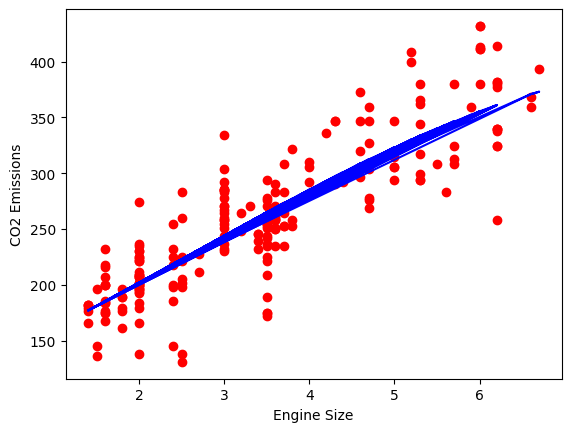

In [9]:
plt.plot(test[['ENGINESIZE']], test_y_, color='blue')
plt.scatter(test[['ENGINESIZE']], test[['CO2EMISSIONS']], color='red')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")